In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [2]:
# convert csv to dataframe
df_final=pd.read_csv("std_enc.csv")
df_final

,ownerNo,modelYear,price,Kms Driven,Mileage,Seats,Fuel type_Cng,Fuel type_Diesel,Fuel type_Electric,Fuel type_Lpg,...,Color_Silver,Color_Star Dust,Color_T Wine,Color_TITANIUM GREY,Color_Taffeta White,Color_Violet,Color_White,Color_Wine Red,Color_Yellow,City_Bangalore
0,3,2015,4.00,120000,23.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,2018,8.11,32706,17.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1,2018,5.85,11949,23.84,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,2014,4.62,17794,19.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,2015,7.90,60000,23.65,5,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,2,2012,16.49,156039,12.55,7,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1316,2,2008,3.30,56000,15.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1317,2,2014,4.25,42000,19.40,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1318,1,2018,7.50,93003,22.54,5,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
# statistical details of the data
df_final.describe()

,ownerNo,modelYear,price,Kms Driven,Mileage,Seats,Fuel type_Cng,Fuel type_Diesel,Fuel type_Electric,Fuel type_Lpg,...,Color_Silver,Color_Star Dust,Color_T Wine,Color_TITANIUM GREY,Color_Taffeta White,Color_Violet,Color_White,Color_Wine Red,Color_Yellow,City_Bangalore
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,...,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.0
mean,1.522727,2016.061364,7.166924,58407.282576,19.328599,5.178030,0.004545,0.271970,0.003788,0.001515,...,0.164394,0.000758,0.000758,0.001515,0.000758,0.000758,0.175000,0.000758,0.003030,1.0
std,0.741552,3.791578,3.680391,32919.619695,4.623748,0.626169,0.067292,0.445143,0.061452,0.038910,...,0.370773,0.027524,0.027524,0.038910,0.027524,0.027524,0.380111,0.027524,0.054986,0.0
min,1.000000,2001.000000,1.000000,150.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,1.000000,2014.000000,4.627500,32736.000000,17.200000,5.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,1.000000,2017.000000,6.375000,54273.500000,18.976467,5.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,2.000000,2019.000000,8.880000,80000.000000,21.460000,5.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,5.000000,2023.000000,18.500000,199000.000000,140.000000,10.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


In [4]:
# create x and y datas

x=df_final.drop(columns=["price"],axis=1)
y=df_final["price"]

In [5]:
# scaling the data with standardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [6]:
import pickle
with open('standard.pkl','wb') as f:
    pickle.dump(scaler,f)

In [7]:
# function to choose the best algorithm

def best_ML_algorithm(x,y,algorithms):
        
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

        results = []

        for algorithm in algorithms:

                model=algorithm().fit(x_train,y_train)
                y_pred=model.predict(x_test)
                MSE_1=mean_squared_error(y_test,y_pred)
                MAE_1=mean_absolute_error(y_test,y_pred)
                RMSE_1=np.sqrt(mean_squared_error(y_test,y_pred))
                r_squr_1=r2_score(y_test,y_pred)
                results.append({"model": type(model).__name__,
                                          "MAE": MAE_1,
                                          "MSE": MSE_1,
                                          "RMSE": RMSE_1,
                                           "R2": r_squr_1 })
                print(f"Trainscore: {model.score(x_train, y_train)}")
                print(f"Testscore: {model.score(x_test, y_test)}")
                # Plot Actual vs Predicted Prices
                plt.figure(figsize=(10, 6))
                sns.scatterplot(x=y_test, y=y_pred)
                plt.xlabel('Actual Prices')
                plt.ylabel('Predicted Prices')
                plt.title(f'{type(model).__name__}: Actual vs Predicted Prices')
                plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # Add reference line
                plt.show()
        results_df = pd.DataFrame(results)
        
        return results_df   

Trainscore: 0.9217762472311808
Testscore: -5.113785158577289e+27


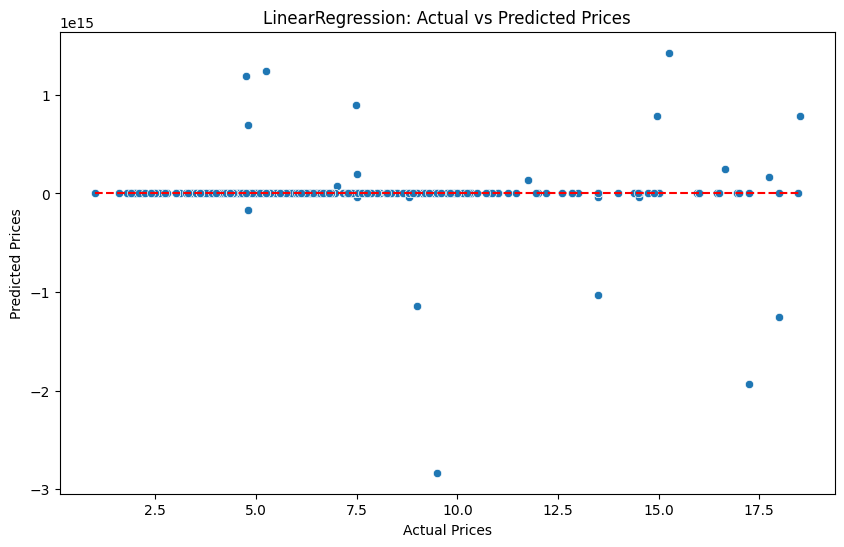

Trainscore: 0.9998694026738537
Testscore: 0.6040820777286595


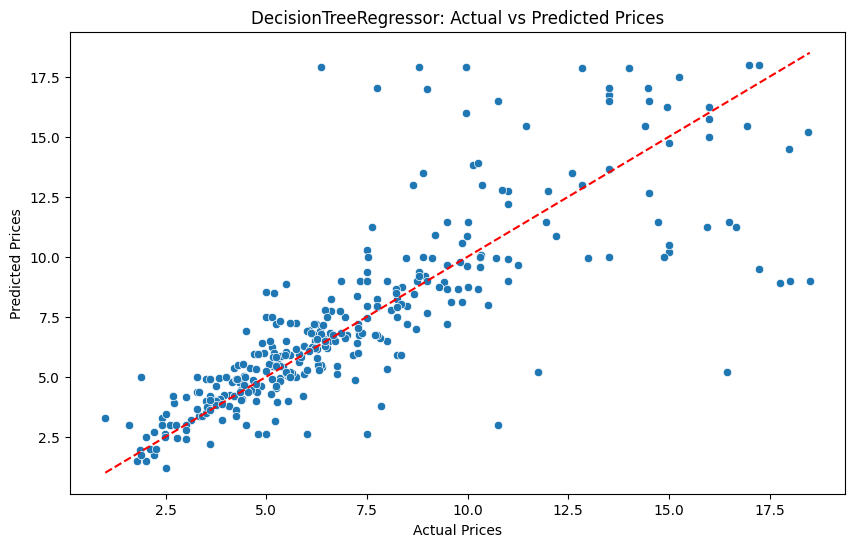

Trainscore: 0.971483108903237
Testscore: 0.7756445468836506


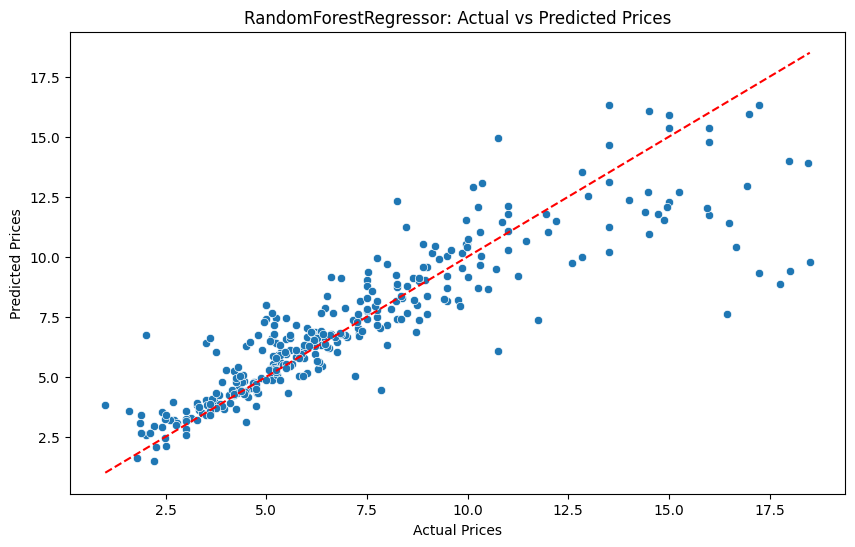

Trainscore: 0.8842158669014379
Testscore: 0.7956131818013051


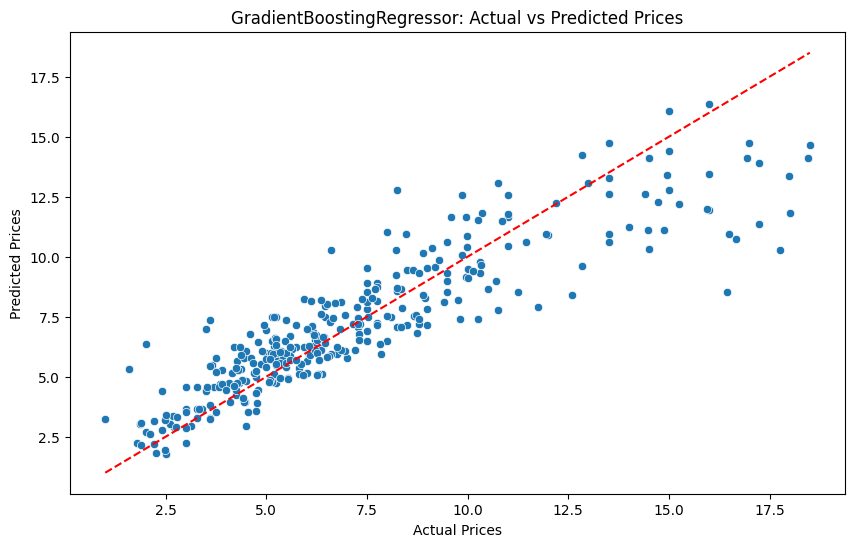

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


# using above function try to identify the best algorithm

algorithms = [LinearRegression, DecisionTreeRegressor, RandomForestRegressor,GradientBoostingRegressor]

results_df = best_ML_algorithm(x_scaled,y, algorithms)

In [9]:
# model comparision
results_df

,model,MAE,MSE,RMSE,R2
0,LinearRegression,4.946951e+13,7.086626e+28,2.662072e+14,-5.113785e+27
1,DecisionTreeRegressor,1.393303e+00,5.486586e+00,2.342346e+00,6.040821e-01
2,RandomForestRegressor,1.068571e+00,3.109093e+00,1.763262e+00,7.756445e-01
3,GradientBoostingRegressor,1.180477e+00,2.832370e+00,1.682965e+00,7.956132e-01


### L1 and L2 Regularization

In [10]:
# using ridge to fit and evalutes the model
from sklearn.linear_model import Ridge
X_train, X_test, Y_train, Y_test = train_test_split(x_scaled, y, test_size=0.25, random_state=42)
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
values=[]
for i in alpha_values:
    ridgeModel = Ridge(alpha=i)
    ridgeModel.fit(X_train,Y_train)
    y_pred=ridgeModel.predict(X_test)
    r_squr=r2_score(Y_test,y_pred)
    values.append(r_squr)

In [11]:
# best alpha values for prediction
best_alpha_ridge = alpha_values[np.argmax(values)]
ridgeModel_1 = Ridge(alpha=best_alpha_ridge)
ridgeModel_1.fit(X_train, Y_train)
y_pred_ridge=ridgeModel_1.predict(X_test)

In [12]:
# model evaluation
MSE_ridge=mean_squared_error(Y_test,y_pred_ridge)
MAE_ridge=mean_absolute_error(Y_test,y_pred_ridge)
RMSE_ridge=np.sqrt(mean_squared_error(Y_test,y_pred_ridge))
r_squr_ridge=r2_score(Y_test,y_pred_ridge)

In [13]:
# create dataframe to view above evaluation metrics
ridge=pd.DataFrame({"model":"RidgeRegressor","MAE":[MSE_ridge],"MSE":[MAE_ridge],"RMSE":[RMSE_ridge],"R2":r_squr_ridge})
ridge

,model,MAE,MSE,RMSE,R2
0,RidgeRegressor,2.700435,1.075115,1.6433,0.805134


In [14]:
# using ridge to fit and evalutes the model
from sklearn.linear_model import Lasso
alpha_values_L = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
values_L=[]
for i in alpha_values_L:
    LassoModel = Lasso(alpha=i)
    LassoModel.fit(X_train,Y_train)
    y_pred=LassoModel.predict(X_test)
    r_squr=r2_score(Y_test,y_pred)
    values_L.append(r_squr)
print(values_L)

[0.8425527691938429, 0.8101014865845386, 0.813462361312093, 0.7822361026971058, 0.36190012578429986, -0.00021263163415663477, -0.00021263163415663477]


c:\Users\nanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.285e+01, tolerance: 1.329e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\nanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.175e+00, tolerance: 1.329e+00
  model = cd_fast.enet_coordinate_descent(


In [15]:
# best alpha values for prediction
best_alpha_lasso = alpha_values_L[np.argmax(values_L)]
LassoModel_1 = Lasso(alpha=best_alpha_lasso)
LassoModel_1.fit(X_train, Y_train)
y_pred_lasso=LassoModel_1.predict(X_test)

c:\Users\nanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.285e+01, tolerance: 1.329e+00
  model = cd_fast.enet_coordinate_descent(


In [16]:
# model evaluation
MSE_lasso=mean_squared_error(Y_test,y_pred_lasso)
MAE_lasso=mean_absolute_error(Y_test,y_pred_lasso)
RMSE_lasso=np.sqrt(mean_squared_error(Y_test,y_pred_lasso))
r_squr_lasso=r2_score(Y_test,y_pred_lasso)

In [17]:
# create dataframe to view above evaluation metrics
lasso=pd.DataFrame({"model":"LassoRegressor","MAE":[MSE_lasso],"MSE":[MAE_lasso],"RMSE":[RMSE_lasso],"R2":r_squr_lasso})
lasso

,model,MAE,MSE,RMSE,R2
0,LassoRegressor,2.181886,1.020473,1.477121,0.842553


In [18]:
# Find the model with the highest R² score 
best_model_df = pd.concat([results_df,ridge,lasso], ignore_index=True)
best_model_df

,model,MAE,MSE,RMSE,R2
0,LinearRegression,4.946951e+13,7.086626e+28,2.662072e+14,-5.113785e+27
1,DecisionTreeRegressor,1.393303e+00,5.486586e+00,2.342346e+00,6.040821e-01
2,RandomForestRegressor,1.068571e+00,3.109093e+00,1.763262e+00,7.756445e-01
3,GradientBoostingRegressor,1.180477e+00,2.832370e+00,1.682965e+00,7.956132e-01
4,RidgeRegressor,2.700435e+00,1.075115e+00,1.643300e+00,8.051338e-01
5,LassoRegressor,2.181886e+00,1.020473e+00,1.477121e+00,8.425528e-01


In [19]:
#convert dataframe to csv
path="ref.csv"
best_model_df.to_csv(path,index=False)

In [20]:
best_model = best_model_df.loc[best_model_df['R2'].idxmax()]
print("Best model with high r2 score")
best_model

Best model with high r2 score


model    LassoRegressor
MAE            2.181886
MSE            1.020473
RMSE           1.477121
R2             0.842553
Name: 5, dtype: object

### Hyperparamater tuning for the best model-LassoRegressor

In [21]:
# parameters for model
from sklearn.model_selection import GridSearchCV

param_grid = { 
    'n_estimators' : [100, 150, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False] 
}

In [22]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Define Lasso model
lasso = Lasso()

# Define parameter grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]  # Regularization strengths
}

# Grid Search with Cross-Validation
grid_tuning = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, n_jobs=-1)

# Fit the model
grid_tuning.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [23]:
grid_tuning.best_params_,grid_tuning.best_score_

({'alpha': 0.01}, 0.813340320759434)

In [24]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Final model using Lasso Regression
final_model = Lasso(alpha=0.016, random_state=42)  # Adjust alpha as needed

# Fit the model
final_model.fit(X_train, Y_train)

# Model evaluation
y_pred_fm = final_model.predict(X_test)
MSE_fm = mean_squared_error(Y_test, y_pred_fm)
MAE_fm = mean_absolute_error(Y_test, y_pred_fm)
RMSE_fm = np.sqrt(mean_squared_error(Y_test, y_pred_fm))
r_squr_fm = r2_score(Y_test, y_pred_fm)

print(f"Train score: {final_model.score(X_train, Y_train)}")
print(f"Test score: {final_model.score(X_test, Y_test)}")

# Create dataframe to view evaluation metrics
rf_1 = pd.DataFrame({"model": "Lasso", "MAE": [MAE_fm], "MSE": [MSE_fm], "RMSE": [RMSE_fm], "R2": r_squr_fm})
rf_1

Train score: 0.9275618130762706
Test score: 0.8133222445518089


,model,MAE,MSE,RMSE,R2
0,Lasso,1.049199,2.586959,1.608403,0.813322


### Store the model using Pickle

In [25]:
import pickle
from sklearn.linear_model import Lasso

# Assuming `final_model` is your trained Lasso model
with open('Lasso_regression.pkl', 'wb') as files:
    pickle.dump(final_model, files)

In [26]:
# load the model,scaler and encoder
with open('Lasso_regression.pkl','rb') as files:
    final_model=pickle.load(files)

with open('standard.pkl','rb') as f:
    scaler=pickle.load(f)

with open('encoder.pkl','rb') as file:
    encoder=pickle.load(file)

### Model system building-pipeline

In [27]:
#read final csv file
df_1=pd.read_csv("final_df.csv")
df_1

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,120000,23.10,5,White,Bangalore
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,32706,17.00,5,White,Bangalore
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,11949,23.84,5,Red,Bangalore
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,17794,19.10,5,Others,Bangalore
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,60000,23.65,5,Gray,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470,Diesel,SUV,Manual,2,Toyota,Toyota Fortuner,2012,16.49,Comprehensive,156039,12.55,7,Blue,Bangalore
1471,Petrol,Sedan,Manual,2,Maruti,Maruti SX4,2008,3.30,Third Party insurance,56000,15.00,5,Red,Bangalore
1472,Petrol,Hatchback,Manual,2,Honda,Honda Brio,2014,4.25,Comprehensive,42000,19.40,5,White,Bangalore
1473,Diesel,Hatchback,Manual,1,Hyundai,Hyundai i20,2018,7.50,Comprehensive,93003,22.54,5,Red,Bangalore


In [28]:
# x and y data splitting
x_df=df_1.drop(columns=["price"],axis=1)
y_df=df_1["price"]

In [29]:
x_df_train, x_df_test, y_df_train, y_df_test = train_test_split(x_df, y_df, random_state=42, test_size=0.2)

In [30]:
# building pipeline for categorical and numerical data
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num=x_df.select_dtypes(include=["int","float"]).columns.to_list()
cat=x_df.select_dtypes(include=["object"]).columns.to_list()

catg_preprocessor=Pipeline(steps=[("categorical",encoder)])
num_preprocessor=Pipeline(steps=[("numerical",scaler)])

In [31]:
# compose preprocessing techniques
preprocessor=ColumnTransformer([("numerical",num_preprocessor,num),
                                ("categorical",catg_preprocessor,cat)])
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('numerical',
                                                  StandardScaler())]),
                                 ['ownerNo', 'modelYear', 'Kms Driven',
                                  'Mileage', 'Seats']),
                                ('categorical',
                                 Pipeline(steps=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Fuel type', 'body type', 'transmission',
                                  'Brand', 'model', 'Insurance Validity',
                                  'Color', 'City'])])

In [32]:
#construct pipeline to combine preprocessor and model
pipeline=Pipeline([("preprocessing",preprocessor),
                   ("model",final_model)])
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('numerical',
                                                                   StandardScaler())]),
                                                  ['ownerNo', 'modelYear',
                                                   'Kms Driven', 'Mileage',
                                                   'Seats']),
                                                 ('categorical',
                                                  Pipeline(steps=[('categorical',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Fuel type', 'body type',
                                                   'transmission', 'Brand',
                                                   'model',
                                                   'Insurance Validity',
                                                   'Color', 'City'])])),
                ('model', Lasso(alpha=0.016, random_state=42))])

In [33]:
# fit with dataframe
pipeline.fit(x_df_train,y_df_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('numerical',
                                                                   StandardScaler())]),
                                                  ['ownerNo', 'modelYear',
                                                   'Kms Driven', 'Mileage',
                                                   'Seats']),
                                                 ('categorical',
                                                  Pipeline(steps=[('categorical',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Fuel type', 'body type',
                                                   'transmission', 'Brand',
                                                   'model',
                                                   'Insurance Validity',
                                                   'Color', 'City'])])),
                ('model', Lasso(alpha=0.016, random_state=42))])

In [34]:
# Predict using the pipeline
y_prediction = pipeline.predict(x_df_test)

# Calculate evaluation metrics
MSE_pipe = mean_squared_error(y_df_test, y_prediction)
MAE_pipe = mean_absolute_error(y_df_test, y_prediction)
RMSE_pipe = np.sqrt(MSE_pipe)
r_squr_pipe = r2_score(y_df_test, y_prediction)

# Create dataframe to view evaluation metrics
Lasso_Pipe = pd.DataFrame({
    "Model": ["Lasso"],
    "MAE": [MAE_pipe],
    "MSE": [MSE_pipe],
    "RMSE": [RMSE_pipe],
    "R2": [r_squr_pipe]
})

Lasso_Pipe

,Model,MAE,MSE,RMSE,R2
0,Lasso,3.06802,54.227806,7.363953,0.292635


In [35]:
x_df.columns

Index(['Fuel type', 'body type', 'transmission', 'ownerNo', 'Brand', 'model',
       'modelYear', 'Insurance Validity', 'Kms Driven', 'Mileage', 'Seats',
       'Color', 'City'],
      dtype='object')

In [36]:
x_df["Brand"].unique()

array(['Maruti', 'Ford', 'Tata', 'Hyundai', 'Jeep', 'Datsun', 'Honda',
       'Mahindra', 'Mercedes-Benz', 'BMW', 'Renault', 'Audi', 'Toyota',
       'Mini', 'Kia', 'Skoda', 'Volkswagen', 'Volvo', 'MG', 'Nissan',
       'Fiat', 'Mahindra Ssangyong', 'Mitsubishi', 'Jaguar', 'Land Rover',
       'Chevrolet', 'Citroen', 'Opel', 'Mahindra Renault'], dtype=object)

In [37]:
df_1[df_1["price"]>45]

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
16,Diesel,SUV,Automatic,1,Mercedes-Benz,Mercedes-Benz GLA,2022,55.95,Comprehensive,16000,18.976467,5,Blue,Bangalore
24,Petrol,Sedan,Automatic,2,Mercedes-Benz,Mercedes-Benz S-Class,2016,49.00,Third Party insurance,50000,7.810000,5,Others,Bangalore
38,Petrol,Sedan,Automatic,1,BMW,BMW 5 Series,2020,49.65,Zero Dep,18157,15.560000,5,Blue,Bangalore
52,Diesel,Sedan,Automatic,1,Mercedes-Benz,Mercedes-Benz E-Class,2022,79.90,Third Party,400,18.976467,5,White,Bangalore
93,Diesel,Sedan,Automatic,2,Mercedes-Benz,Mercedes-Benz E-Class,2018,59.90,Comprehensive,24000,17.000000,5,White,Bangalore
164,Petrol,Sedan,Automatic,1,BMW,BMW 6 Series,2022,79.00,Comprehensive,4000,13.320000,4,Blue,Bangalore
226,Diesel,SUV,Automatic,2,BMW,BMW X5,2019,67.95,Comprehensive,77000,13.380000,5,White,Bangalore
311,Diesel,SUV,Automatic,1,BMW,BMW X4,2020,60.50,Comprehensive,55000,14.710000,5,White,Bangalore
419,Diesel,Sedan,Automatic,1,BMW,BMW 5 Series,2018,49.50,Comprehensive,50000,17.420000,5,Blue,Bangalore
444,Petrol,Sedan,Automatic,1,BMW,BMW 3 Series,2022,55.00,Third Party insurance,10000,16.130000,5,Others,Bangalore


In [38]:
df_1.loc[24]

Fuel type                            Petrol
body type                             Sedan
transmission                      Automatic
ownerNo                                   2
Brand                         Mercedes-Benz
model                 Mercedes-Benz S-Class
modelYear                              2016
price                                  49.0
Insurance Validity    Third Party insurance
Kms Driven                            50000
Mileage                                7.81
Seats                                     5
Color                                Others
City                              Bangalore
Name: 24, dtype: object

In [39]:
x_df[x_df["Brand"]=="BMW"]

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
20,Diesel,Sedan,Automatic,3,BMW,BMW 5 Series,2011,Third Party insurance,100000,18.48,5,White,Bangalore
38,Petrol,Sedan,Automatic,1,BMW,BMW 5 Series,2020,Zero Dep,18157,15.56,5,Blue,Bangalore
72,Diesel,Sedan,Automatic,1,BMW,BMW 3 Series GT,2016,Comprehensive,40525,21.76,5,White,Bangalore
88,Diesel,SUV,Automatic,2,BMW,BMW X3,2016,Comprehensive,92000,16.55,5,White,Bangalore
116,Diesel,Sedan,Automatic,2,BMW,BMW 3 Series,2008,Third Party insurance,80000,13.20,5,Others,Bangalore
136,Diesel,SUV,Automatic,2,BMW,BMW X5,2016,Third Party insurance,70000,15.97,5,Others,Bangalore
138,Diesel,Sedan,Automatic,2,BMW,BMW 3 Series,2010,Third Party insurance,70000,16.07,5,Others,Bangalore
164,Petrol,Sedan,Automatic,1,BMW,BMW 6 Series,2022,Comprehensive,4000,13.32,4,Blue,Bangalore
226,Diesel,SUV,Automatic,2,BMW,BMW X5,2019,Comprehensive,77000,13.38,5,White,Bangalore
248,Petrol,Coupe,Automatic,3,BMW,BMW 3 Series,2007,Third Party insurance,50000,10.90,5,Others,Bangalore


In [40]:
df_1.iloc[20]

Fuel type                            Diesel
body type                             Sedan
transmission                      Automatic
ownerNo                                   3
Brand                                   BMW
model                          BMW 5 Series
modelYear                              2011
price                                  22.0
Insurance Validity    Third Party insurance
Kms Driven                           100000
Mileage                               18.48
Seats                                     5
Color                                 White
City                              Bangalore
Name: 20, dtype: object

### Model Prediction

In [41]:
# New data to predict car price
new_df=pd.DataFrame({
    'Fuel type':'Disel',
    'body type':'Sedan',
    'transmission':'Automatic',
    'ownerNo':3,
    'Brand':'BMW',
    'model':'BMW 5 Series',
    'modelYear':2011,
    'Insurance Validity': 'Third Party insurance',
    'Kms Driven':100000.0,
    'Mileage':18,
    'Seats':5,
    'Color':'White',
    'City':'Bangalore'
},index=[0])
new_df

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
0,Disel,Sedan,Automatic,3,BMW,BMW 5 Series,2011,Third Party insurance,100000.0,18,5,White,Bangalore


In [42]:
# FINAL MODEL PREDICTION 
prediction=pipeline.predict(new_df)
print(f"The price of the {new_df['Brand'].iloc[0]} car is: {round(prediction[0],2)} lakhs")

The price of the BMW car is: 27.48 lakhs


In [43]:
# save the pipeline in pickle

with open('pipeline.pkl','wb') as files:
    pickle.dump(pipeline,files)